In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

# Data import
- data = unirep features of the filtered library peptides
- peptides = peptide sequences that correspond to data
- orig_peptides = peptide sequences of library of FBDD manuscript
- orig_lib = unirep features of orig_peptides
- pagg_lib = unirep features of published library for testing PagG (10.1021/acscatal.0c00623)

In [2]:
data = np.load('../encoding/unirep_5mer_lib.npy')
orig_peptides = np.load('original_peptides.npy')
peptides = np.load('../220510_5mer_library.npy')
orig_lib = np.load('unirep_orig_lib.npy')
pagg_lib = np.load('unirep_pagg_lib.npy')
pagg_pepseqs = np.load('pagg_lib.npy')
peptides = np.array([i[:5] for i in peptides]) # cut off constant region

n = round(data.shape[1])
df = pd.DataFrame(data[:, :n], index=peptides, columns = ['f'+str(i+1) for i in range(n)])

orig_df = pd.DataFrame(orig_lib, index=orig_peptides, columns = ['f'+str(i+1) for i in range(n)])
pagg_df = pd.DataFrame(pagg_lib, index=pagg_pepseqs, columns = ['f'+str(i+1) for i in range(n)])

df = df.loc[:, (df != 0).any(axis=0)]
df.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f1891,f1892,f1893,f1894,f1895,f1896,f1897,f1898,f1899,f1900
GADEF,0.088081,0.009338,-0.065617,0.095007,-0.019542,0.123355,-0.478922,0.081878,-0.103119,0.340690,...,0.081366,0.206757,-0.042708,0.092970,0.096515,0.086592,0.128984,0.075844,0.100289,0.147611
GADEY,0.087717,0.001923,-0.064906,0.094970,-0.018008,0.120416,-0.486670,0.082191,-0.103004,0.364526,...,0.081988,0.213068,-0.034552,0.093551,0.097330,0.083450,0.110797,0.076784,0.100077,0.153797
GADEW,0.087417,0.010377,-0.064905,0.095069,-0.025019,0.118051,-0.539491,0.082061,-0.103094,0.357155,...,0.081070,0.217500,-0.058845,0.093839,0.097736,0.083797,0.133911,0.072035,0.104962,0.160443
GAEDF,0.088011,0.014842,-0.066400,0.095073,-0.023149,0.108661,-0.511065,0.082422,-0.103102,0.394067,...,0.080354,0.173559,-0.023201,0.093363,0.094061,0.083529,0.136344,0.069250,0.100708,0.149032
GAEDY,0.087580,0.007398,-0.065931,0.095051,-0.023436,0.106679,-0.521790,0.082775,-0.102975,0.426781,...,0.080429,0.187575,-0.024757,0.093796,0.094250,0.080417,0.116422,0.066809,0.098368,0.153544


In [3]:
all_pep = pd.concat([df, orig_df, pagg_df])

scaler = StandardScaler()
scaler.fit(all_pep)

all_pep = scaler.transform(all_pep)

df = scaler.transform(df)
df = pd.DataFrame(df, index=peptides, columns = ['f'+str(i+1) for i in range(n)])

orig_df = scaler.transform(orig_df)
orig_df = pd.DataFrame(orig_lib, index=orig_peptides, columns = ['f'+str(i+1) for i in range(n)])

pagg_df = scaler.transform(pagg_df)
pagg_df = pd.DataFrame(pagg_lib, index=pagg_pepseqs, columns = ['f'+str(i+1) for i in range(n)])

# Dimensionality reduction and KMedoid clustering
The medoids are thought to be representative picks for the testing library

In [4]:
pca = PCA()
pca.fit(df)
X_transform = pca.transform(df)
print(X_transform.shape)
print(orig_lib.shape)
print(pagg_lib.shape)

(211320, 1900)
(80, 1900)
(120, 1900)


In [5]:
#try pca of concatenated peptide libraries
#all_pep = pd.concat([df, orig_df, pagg_df])
pca = PCA()
pca.fit(all_pep)
X_transform = pca.transform(all_pep)

In [6]:
var_threshold = 0.9
var_expl = sum(pca.explained_variance_ratio_.cumsum() < var_threshold)
print('{0}% of the variance is explained by the first {1} principle components'.format(var_threshold*100, var_expl))

90.0% of the variance is explained by the first 177 principle components


In [ ]:
kmed = KMedoids(n_clusters=120, random_state=42, 
                init='k-medoids++').fit(X_transform[:, :var_expl])
medoid_library = peptides[kmed.medoid_indices_]
#np.save('5mer-kmed_Z',kmed)
#np.save('5mer-medoids_Z', medoid_library)

In [ ]:
np.save('5mer-kmed_Z',kmed)
np.save('5mer-medoids_Z', medoid_library)

In [7]:
medoid_library = np.load('5mer_analysis/5mer-medoids.npy')
kmed = np.load('5mer_analysis/5mer-kmed-centers.npy')#, allow_pickle = True)


Text(0.5, 1.0, 'Medoids n=120')

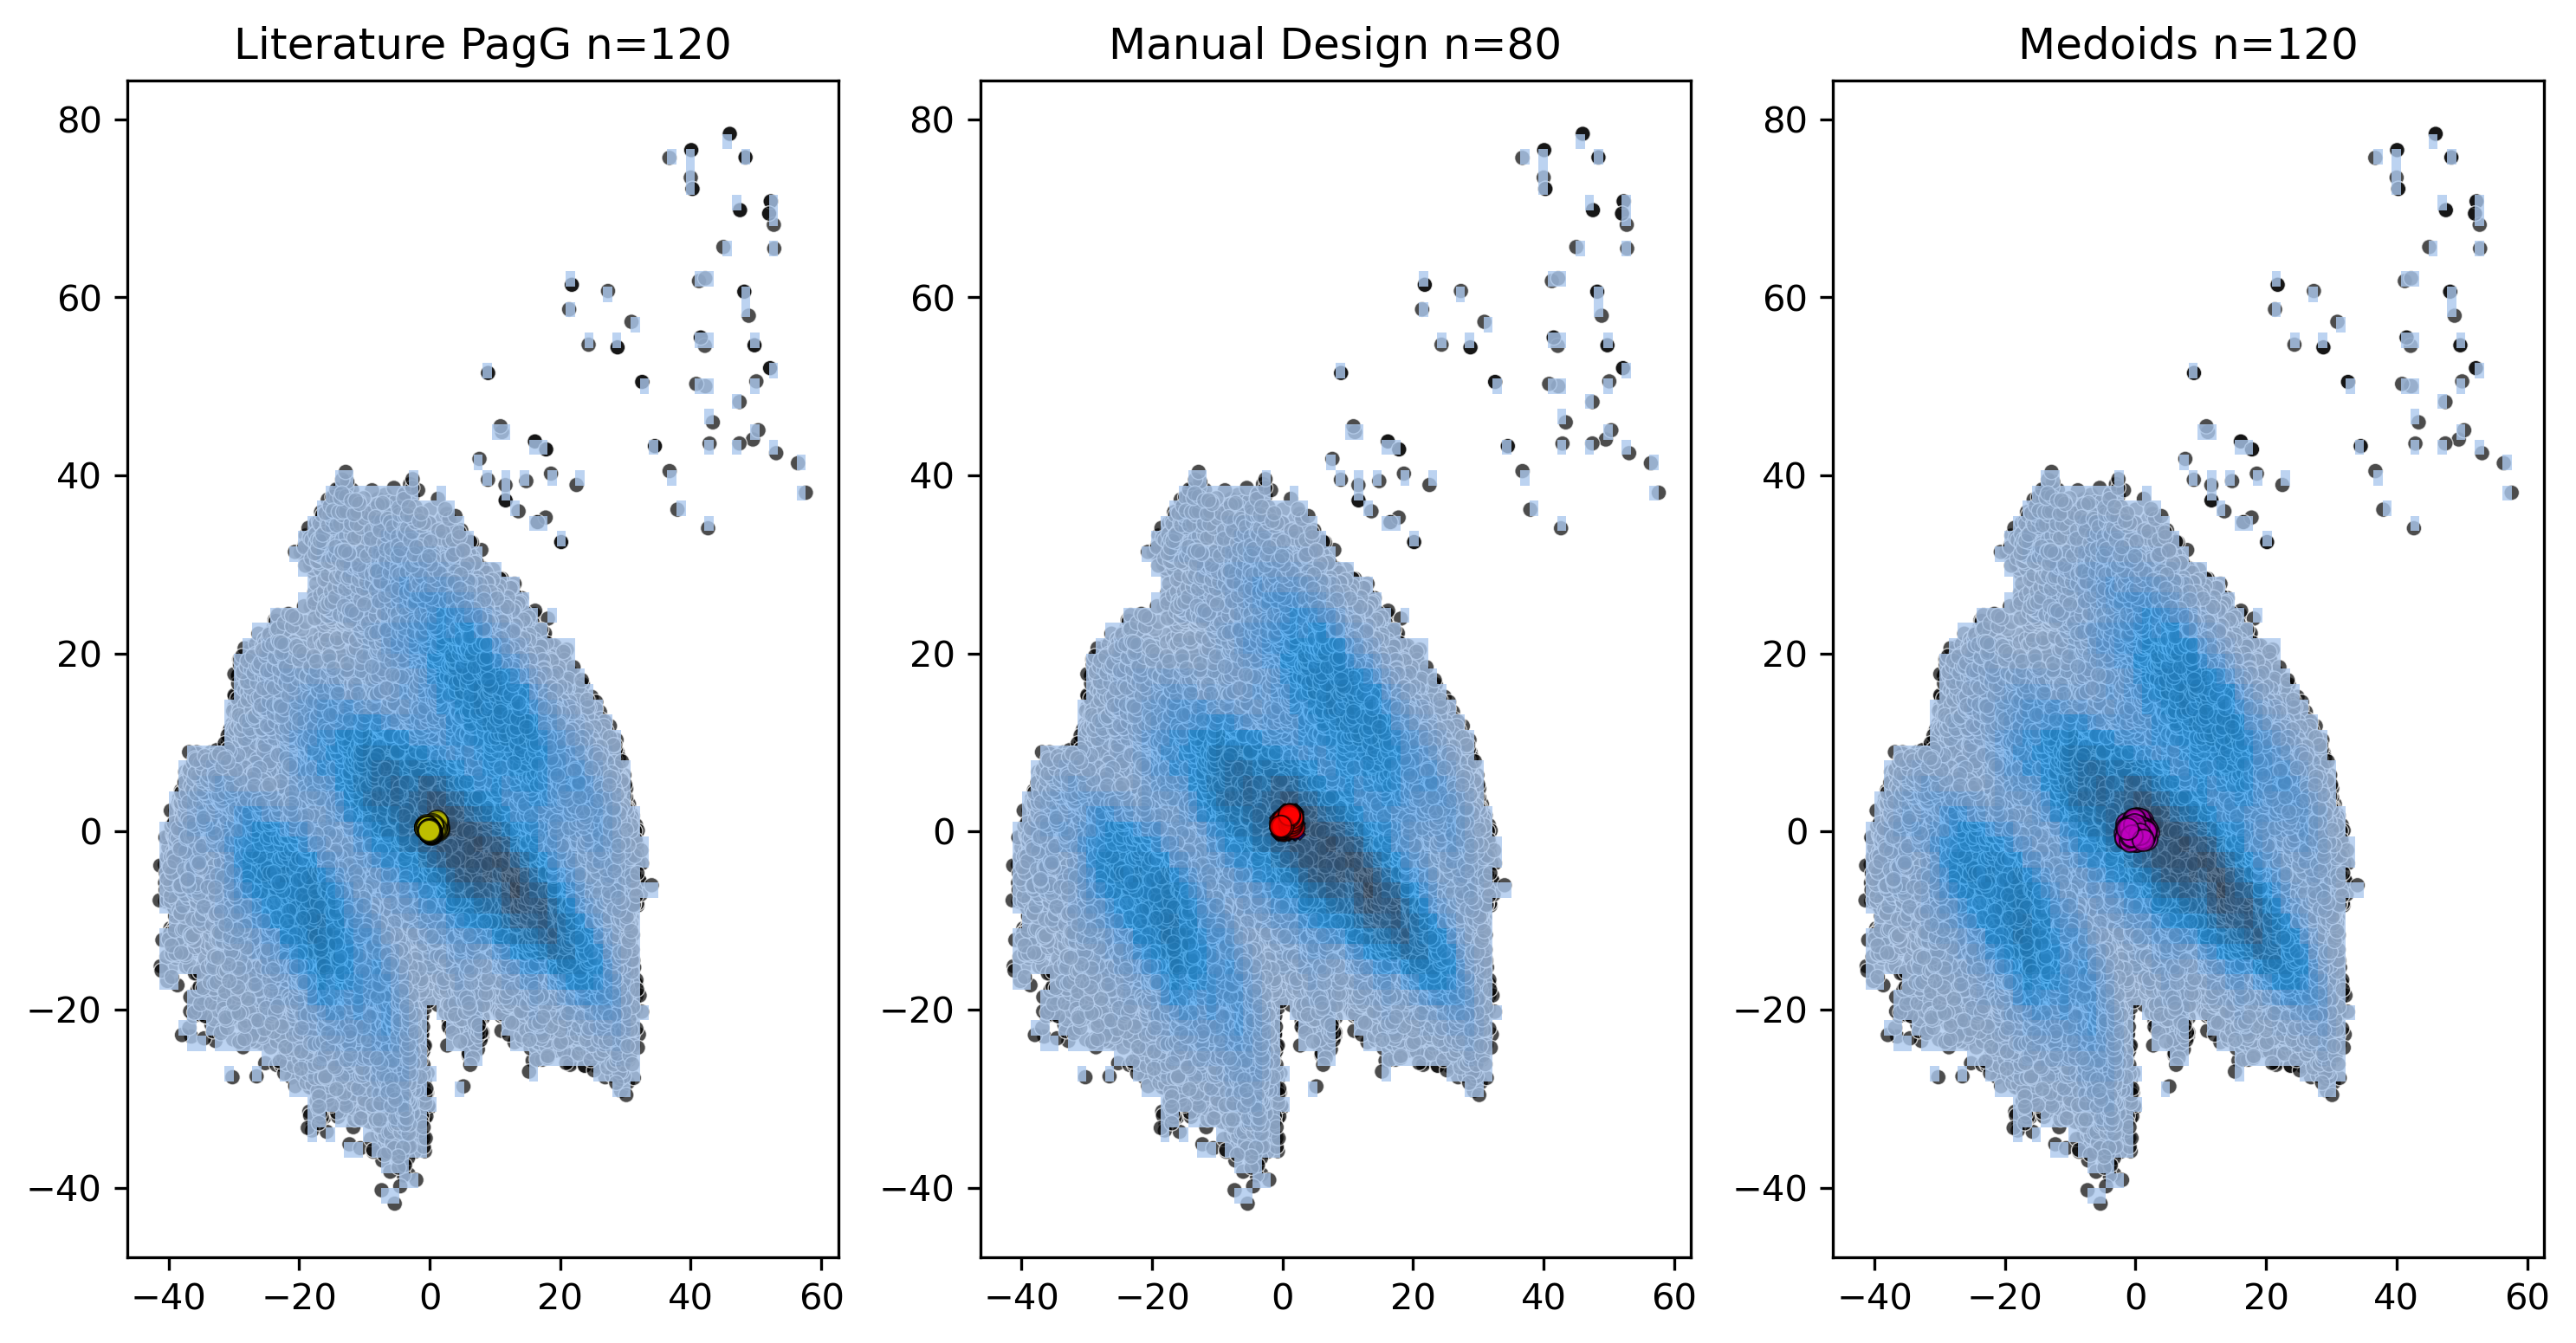

In [8]:
# visually inspect the diversity of the generated library in the unirep space
xx, yy = 0, 1

fig, axs = plt.subplots(1, 3, figsize=(12, 6), dpi = 300)

# lay down whole library
for ax in axs:
    sns.scatterplot(x=X_transform[:, xx], y=X_transform[:, yy], alpha=0.7, 
                    color='k', size=0.1, legend=False, ax=ax)
    sns.histplot(x=X_transform[:, xx], y=X_transform[:, yy], bins=70, alpha=0.8, ax=ax)

# plot pca transformed PagG library
sns.scatterplot(x=pca.transform(pagg_lib)[:, xx],
                y=pca.transform(pagg_lib)[:, yy],
                color='y',
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[0])

# manually designed FBDD library
# blue = original
# red = PatG adapted version
sns.scatterplot(x=pca.transform(orig_lib)[:, xx],
                y=pca.transform(orig_lib)[:, yy], 
                c=np.concatenate((['b' for i in range(40)],
                                  ['r' for i in range(40)])),
                palette='deep',
                style=np.concatenate(([3 for i in range(40)],
                                      [2 for i in range(40)])),
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[1])

# plot KMedoid generated library 
sns.scatterplot(x=kmed[:, xx],
                y=kmed[:, yy],
                color='m',
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[2])

axs[0].set_title('Literature PagG n={0}'.format(len(pagg_lib)))
axs[1].set_title('Manual Design n={0}'.format(len(orig_lib)))
axs[2].set_title('Medoids n={0}'.format(len(kmed)))

#plt.savefig('Library in Unirep space')

In [26]:
cat_dict = {'neut': ['G', 'A', 'V', 'I', 'L', 'N', 'Q', 'H'],
            'neg': ['D', 'E'],
            'aromat': ['F', 'Y', 'W'],
            'basic': ['K', 'R'],
            'het': ['S', 'T']
            } 
medoid_library = np.sort(medoid_library)
#for i in medoid_library:
#    print(i)

In [27]:
list(cat_dict.keys())

['neut', 'neg', 'aromat', 'basic', 'het']

In [28]:
def make_colors(seq_list):
    cat_list = [0]*8+[1]*2+[2]*3+[3]*2+[4]*2
    aa_list = ['G', 'A', 'V', 'I', 'L', 'N', 'Q', 'H']+['D', 'E']+['F', 'Y', 'W']+['K', 'R']+['S', 'T']
    category_seqs = {}
    for sequence in seq_list:
        seq = []
        for aa in sequence:
            seq.append(cat_list[aa_list.index(aa)])
        category_seqs[sequence] = seq
    return(category_seqs)
        

In [29]:
col_plot = make_colors(medoid_library)
col_plot = pd.DataFrame(col_plot).T

col_plot = col_plot.sort_values(by = list(col_plot.columns))
y_ticks = list(col_plot.index)

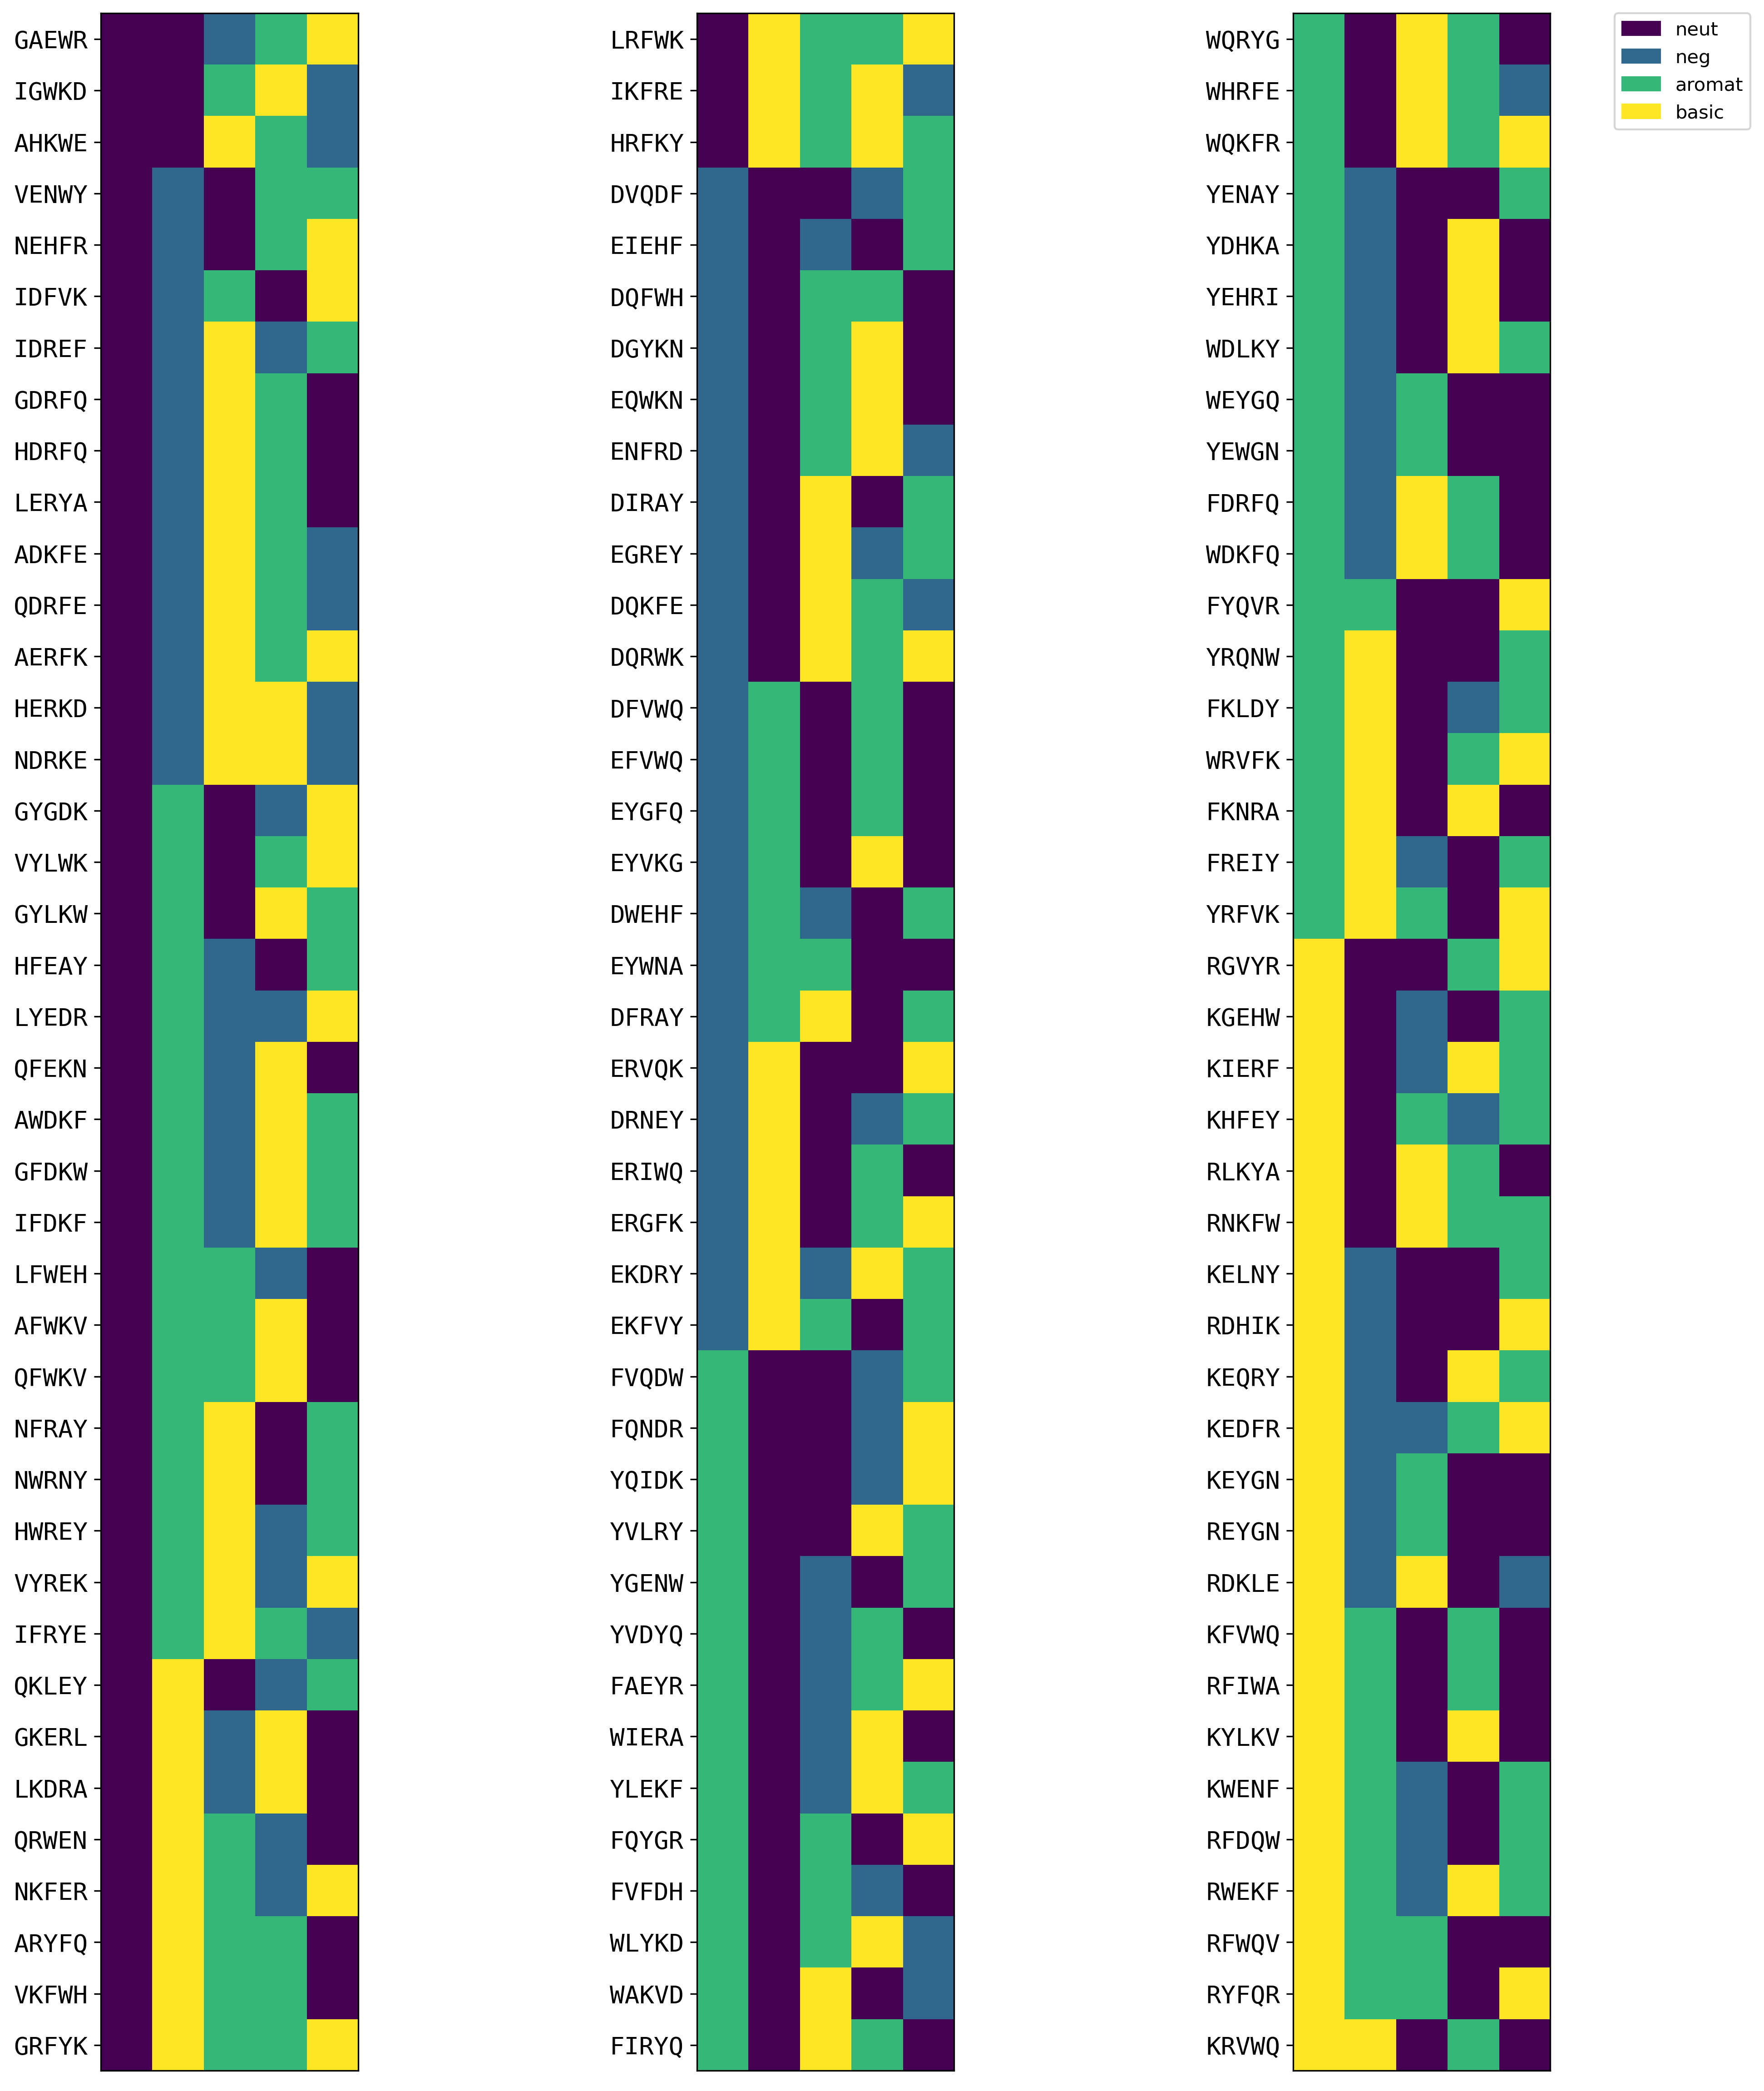

In [32]:
import matplotlib.patches as mpatches
fig, axs = plt.subplots(1, 3, figsize=(16, 20))
division = int(len(col_plot)/3)
fig.set_dpi(300.0)

im = axs[0].imshow(col_plot[:division])

axs[1].imshow(col_plot[division:division*2])
axs[2].imshow(col_plot[division*2:])

axs[0].set_xticks([])
axs[1].set_xticks([])
axs[2].set_xticks([])

axs[0].set_yticks(range(division))
axs[1].set_yticks(range(division))
axs[2].set_yticks(range(division))

font_dict = {'family': 'monospace', 'fontsize': 13}

axs[0].set_yticklabels(y_ticks[:division], fontdict = font_dict)
axs[1].set_yticklabels(y_ticks[division:division*2], fontdict = font_dict)
axs[2].set_yticklabels(y_ticks[division*2:], fontdict = font_dict)

values = list(range(4))
colors = [ im.cmap(im.norm(value)) for value in values]

# create a patch (proxy artist) for every color 
patches = [ mpatches.Patch(color=colors[i], label=list(cat_dict.keys())[i] ) for i in range(len(values)) ]
plt.legend(handles=patches, bbox_to_anchor=(1.25, 1), loc=2, borderaxespad=0. )
#plt.savefig('library_draft')

# Manual Filtering

In [33]:
# list to remove
delete = ['YQIDK','FKNRA','ADFKE', 'DRNEY', 'DQRWK', 'EKDRY', 'FYQVR', 'QDRFE', 'NWRNY', 'NDRKE', 'LYEDR', 'KRVWQ', 'KIERF', 'KEQRY', 'KEDFR', 'IKFRE', 'IDREF', 'HERKD', 'RDHIK','RDKLE','RGVYR','RLKYA','RNKFW','RWEKF','RYFQR','WQKFR','WRVFK']
final_lib = medoid_library
for de in delete:
    final_lib = final_lib[final_lib!=de]
#final_lib = np.append(final_lib,'LDWEF')
#final_lib = np.append(final_lib,'TAAAI')

In [34]:
final_lib.shape

(94,)

In [35]:
col_plot = make_colors(final_lib)
col_plot = pd.DataFrame(col_plot).T

col_plot = col_plot.sort_values(by = list(col_plot.columns))
y_ticks = list(col_plot.index)

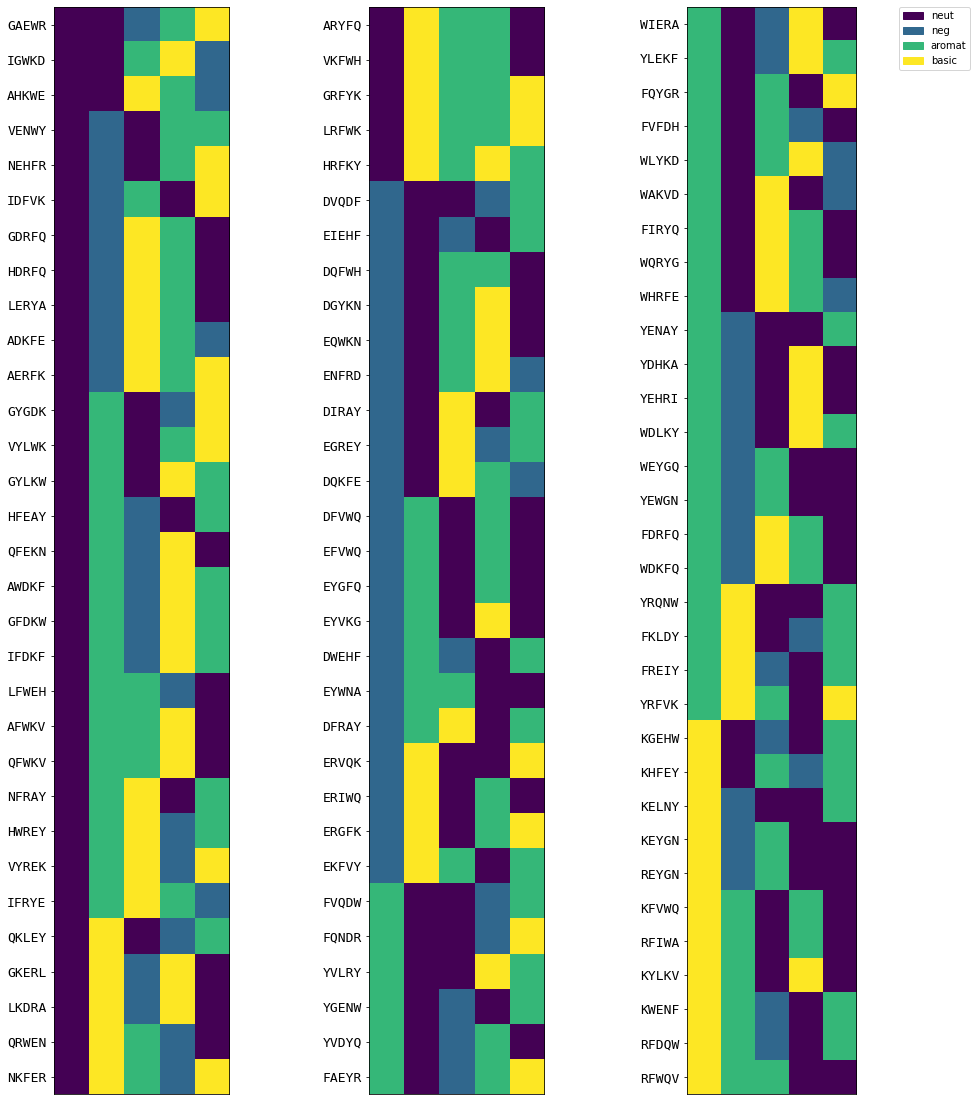

In [37]:
import matplotlib.patches as mpatches
fig.set_dpi(300.0)
fig, axs = plt.subplots(1, 3, figsize=(16, 20))
division = int(len(col_plot)/3)

im = axs[0].imshow(col_plot[:division])

axs[1].imshow(col_plot[division:division*2])
axs[2].imshow(col_plot[division*2:])

axs[0].set_xticks([])
axs[1].set_xticks([])
axs[2].set_xticks([])

axs[0].set_yticks(range(len(y_ticks[:division])))
axs[1].set_yticks(range(len(y_ticks[division:division*2])))
axs[2].set_yticks(range(len(y_ticks[division*2:])))

font_dict = {'family': 'monospace', 'fontsize': 13}

axs[0].set_yticklabels(y_ticks[:division], fontdict = font_dict)
axs[1].set_yticklabels(y_ticks[division:division*2], fontdict = font_dict)
axs[2].set_yticklabels(y_ticks[division*2:], fontdict = font_dict)

values = list(range(4))
colors = [ im.cmap(im.norm(value)) for value in values]

# create a patch (proxy artist) for every color 
patches = [ mpatches.Patch(color=colors[i], label=list(cat_dict.keys())[i] ) for i in range(len(values)) ]
plt.legend(handles=patches, bbox_to_anchor=(1.25, 1), loc=2, borderaxespad=0. )
#plt.savefig('curated_library')

In [119]:
outfile = open('final_lib.txt','w')
for i in final_lib:
    member_seq = str(i)+'TAPAYDG\n'
    outfile.write(member_seq)

In [50]:
ham = []
for i in range(len(final_lib)):
    j = 0
    hi = []
    while j < len(final_lib):
        hi.append(hamming_dist(final_lib[i], final_lib[j]))
        j += 1
    ham.append(hi)
ham = pd.DataFrame(ham, index = final_lib)

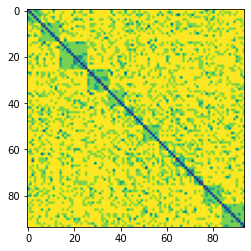

In [51]:
plt.imshow(ham)

In [56]:
import scipy.spatial as sp, scipy.cluster.hierarchy as hc
linkage = hc.linkage(sp.distance.squareform(ham), method='complete')


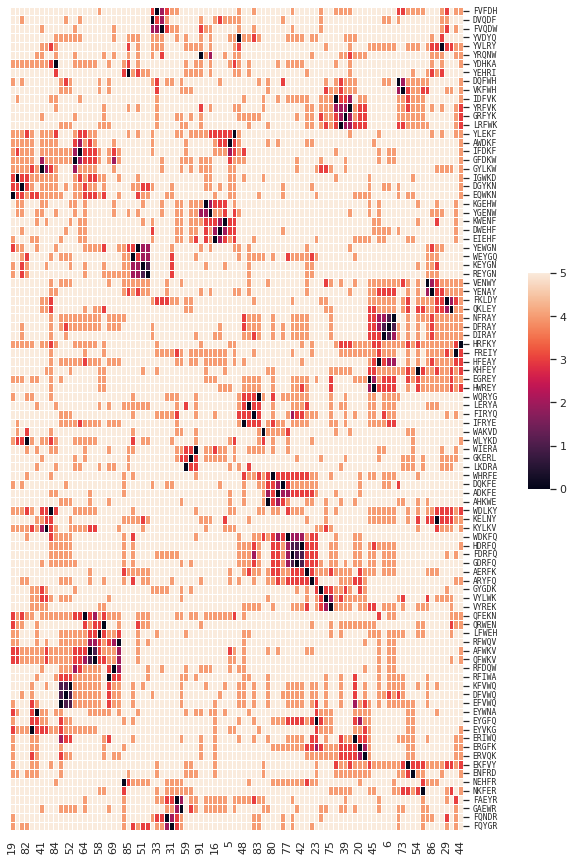

In [72]:
sns.set(rc={'axes.facecolor':'white', 'figure.facecolor':'white'})
g = sns.clustermap(ham, dendrogram_ratio=(.29, .2),
                   cbar_pos=(1, .35, .03, .2), method='ward', 
                   linewidths=.75, figsize=(10, 15), row_linkage=linkage)

g.ax_heatmap.set_yticks(np.arange(len(g.data2d.index))+0.5)
g.ax_heatmap.set_yticklabels(g.data2d.index, fontdict = {'fontsize': 8, 'va': 'center', 'family':'monospace'})
g.ax_col_dendrogram.remove()
g.ax_row_dendrogram.remove()
g.savefig('hamming_cluster')

In [143]:
ordered = list(g.data2d.index)
clu1 = ordered[0:3]
clu2 = ordered[3:8]
clu3 = ordered[8:14]
clu4 = ordered[14:22]
clu5 = ordered[22:27]
clu6 = ordered[27:31]
clu7 = ordered[31:44]
clu8 = ordered[44:48]
clu9 = ordered[48:53]
clu10 = ordered[53:57]
clu11 = ordered[57:60]
clu12 = ordered[60:66]
clu13 = ordered[66:69]
clu14 = ordered[69:75]
clu15 = ordered[75:80]
clu16 = ordered[80:86]
clu17 = ordered[86:90]
clu18 = ordered[90:]
clu18

['FAEYR', 'GAEWR', 'FQNDR', 'FQYGR']

In [159]:
clu1 = ['FVFDH', 'DVQAF', 'FVADW']
clu2[2:] = ['YRGAW', 'YDAHA', 'YLHRI']
clu3[-1] = 'LAKWG'
clu5[-1] = 'VIALY'
clu6[0] = 'FDWGA'
clu7 =  ['VENWY', 'YEIAY', 'FKLDY', 'QKLEY', 'NFRAF', 'DFRIY', 'AIRGY', 'HRFLW', 'FAKIY', 'HFEAY', 'KHFAA', 'EGREY', 'HWREF']
clu9[2:] = ['WIETA', 'GKTRL', 'LGGRA']
clu10 = ['WHRFT', 'DTKFE', 'ADKFE', 'AIKWE']
clu12[1:] = ['HYDAQ', 'FDRFQ', 'GRFQT', 'GGRFK', 'ARYFQ']
clu14[:3] = ['IFGKN', 'QRWET', 'LFWDT']
clu15[-2:] = ['AIFKV','FIETW']
clu16[1] = 'TYGFG' 
clu17[0] = 'DKFVY'
clu18[-1] = 'FQYTR'
curated_peptide_list = clu1+clu2+clu3+clu4+clu5+clu6+clu7+clu8+clu9+clu10+clu11+clu12+clu13+clu14+clu15+clu16+clu17+clu18
curated_peptide_list = np.save('curated_peptide_list',list(set(curated_peptide_list+['TAASI', 'LDWEF'])))


In [2]:
curated_library_unirep = np.load('curated_peptide_list.npy')

In [4]:
curated_library_unirep[0]

'DVQAF'

Text(0.5, 1.0, 'Medoids n=120')

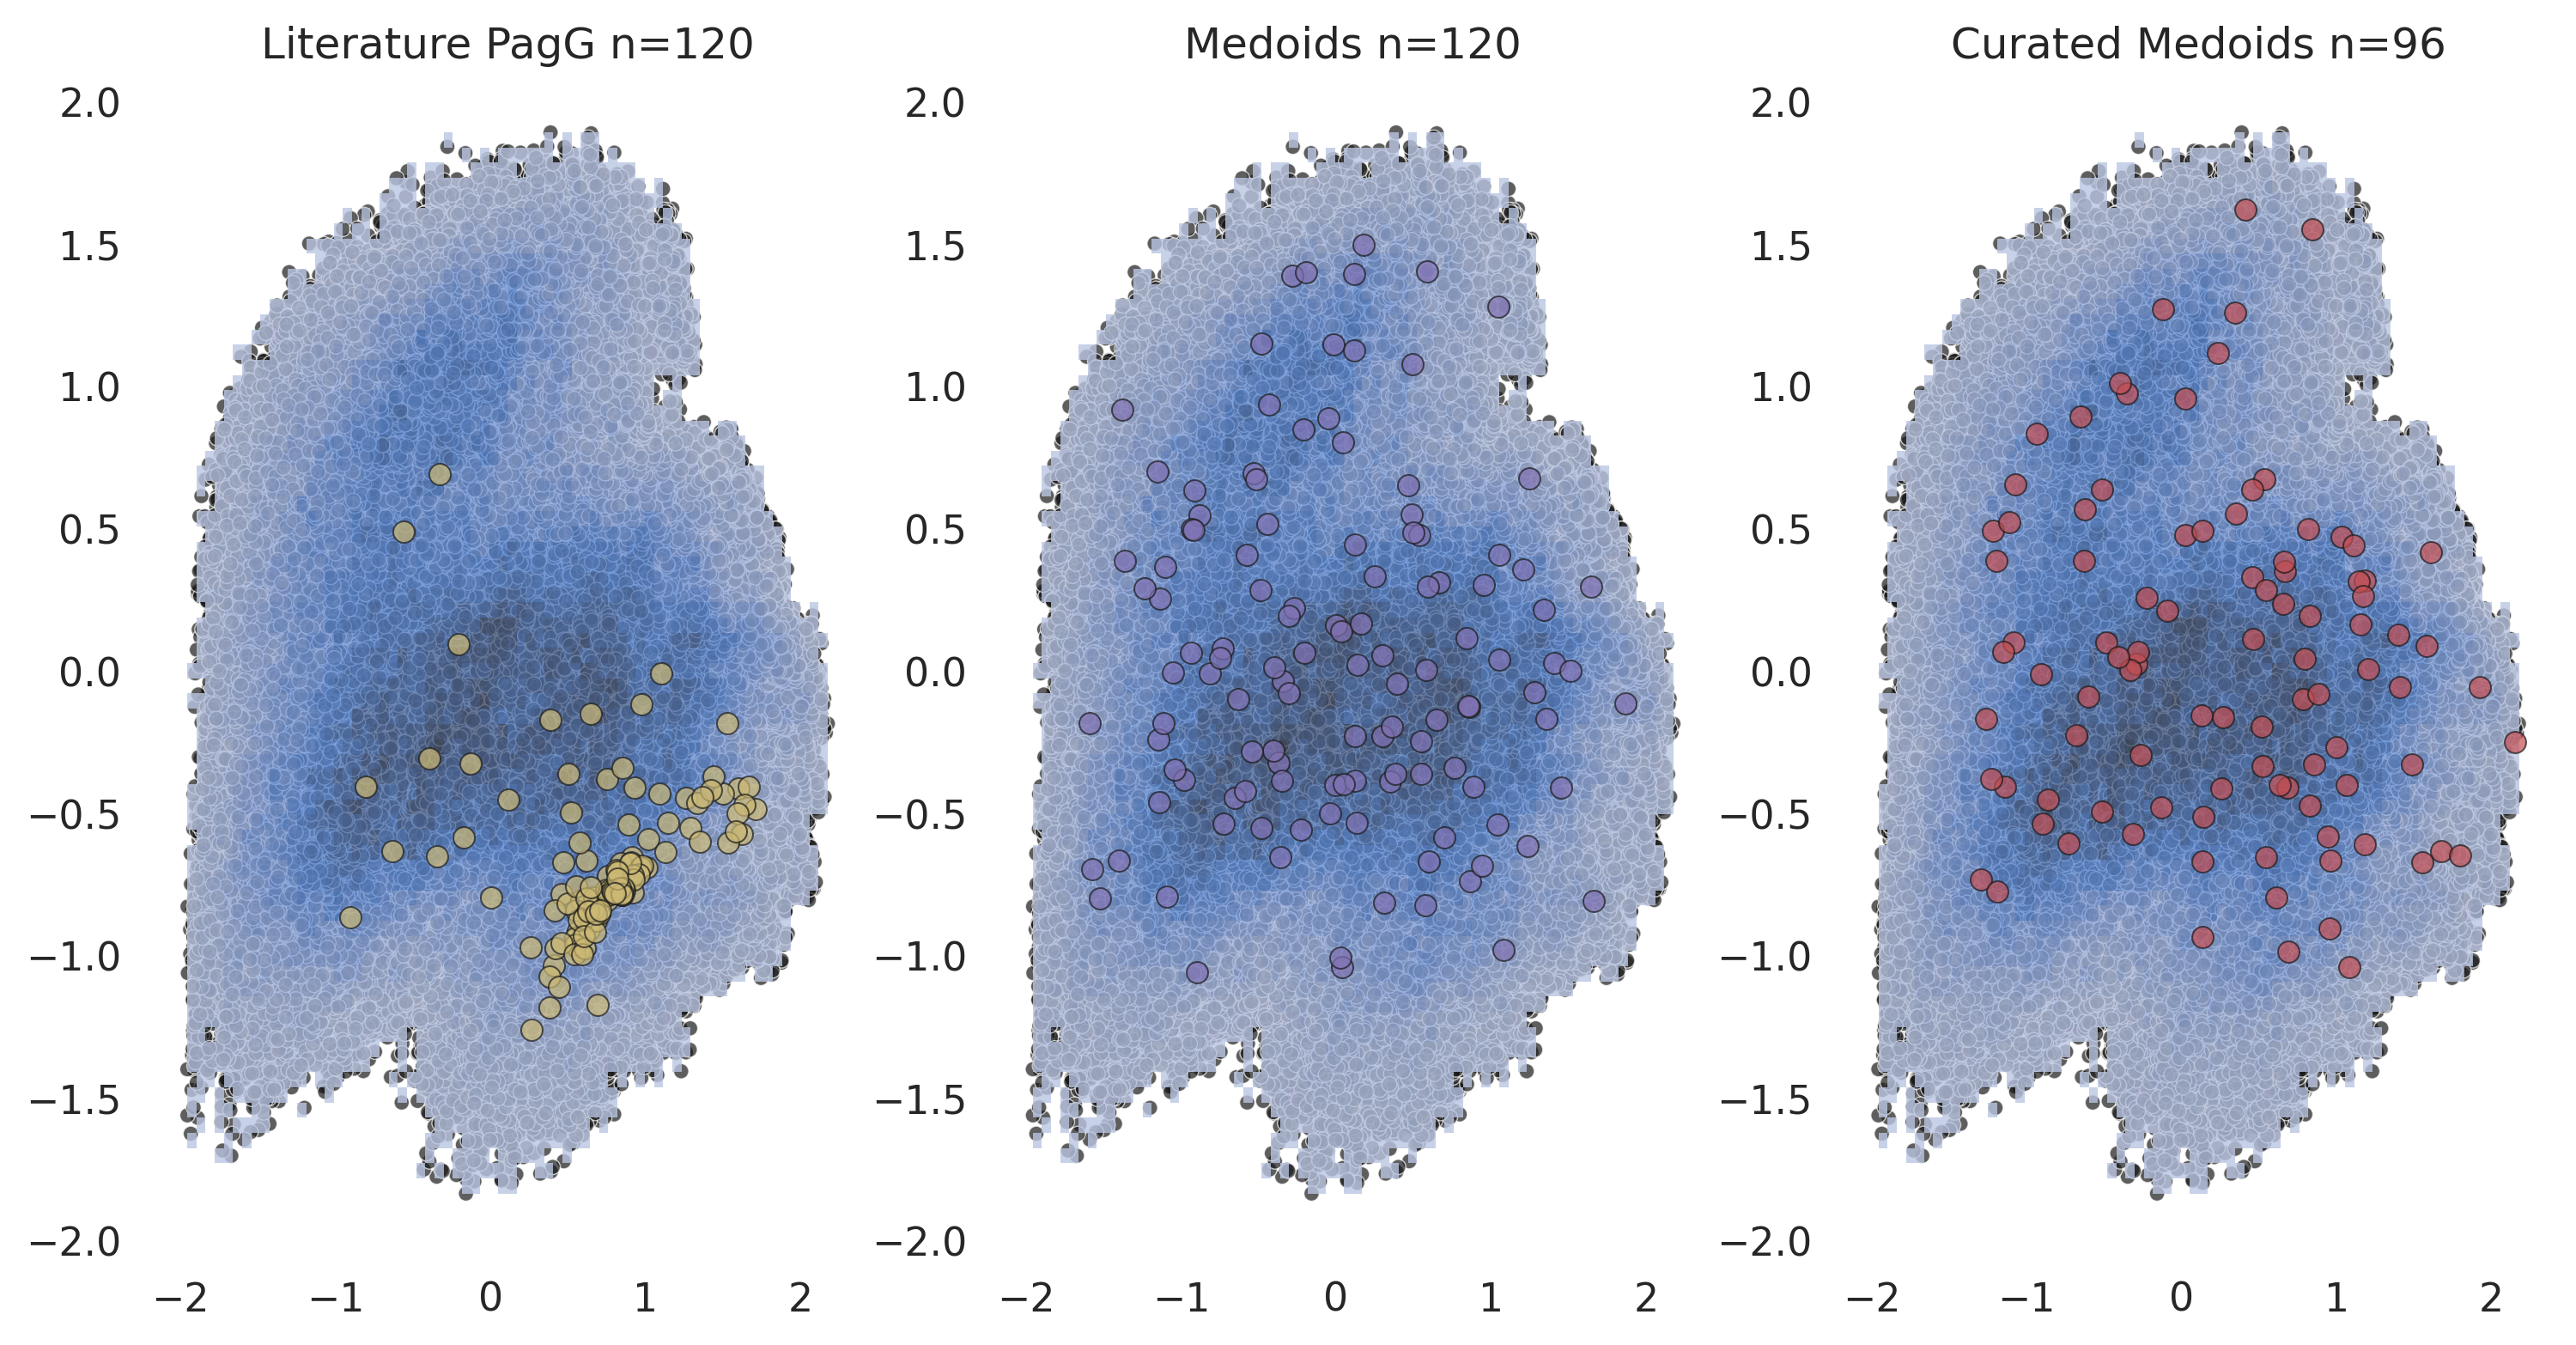

In [156]:
# visually inspect the diversity of the generated library in the unirep space
xx, yy = 0, 1

fig, axs = plt.subplots(1, 3, figsize=(12, 6), dpi = 300)

# lay down whole library
for ax in axs:
    sns.scatterplot(x=X_transform[:, xx], y=X_transform[:, yy], alpha=0.7, 
                    color='k', size=0.01, legend=False, ax=ax)
    sns.histplot(x=X_transform[:, xx], y=X_transform[:, yy], bins=70, alpha=0.8, ax=ax)

# plot pca transformed PagG library
sns.scatterplot(x=pca.transform(pagg_lib)[:, xx],
                y=pca.transform(pagg_lib)[:, yy],
                color='y',
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[0])

# manually designed FBDD library
# blue = original
# red = PatG adapted version
sns.scatterplot(x=pca.transform(curated_library_unirep)[:, xx],
                y=pca.transform(curated_library_unirep)[:, yy], 
                palette='deep',
                color = 'r',
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[2])

# plot KMedoid generated library 
sns.scatterplot(x=kmed[:, xx],
                y=kmed[:, yy],
                color='m',
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[1])

axs[0].set_title('Literature PagG n={0}'.format(len(pagg_lib)))
axs[2].set_title('Curated Medoids n={0}'.format(len(curated_peptide_list)))
axs[1].set_title('Medoids n={0}'.format(len(kmed)))

#plt.savefig('Library in Unirep space')

In [158]:
with open('final_final_library.txt','w') as out:
    for i in curated_peptide_list:
        out.write(i+'TAPAYDG\n')

# Investigation of data's internal structure
check for artifacts by *a)* looking at the whole library's pca projection
*b)* euclidean distances of all library members and the generated
screening library in the unirep space *c)* hamming distance between library members

In [174]:
# Look at unirep space of whole library to rule out artifacts
df2 = pd.DataFrame(X_transform, 
                  columns=['PC'+str(i+1) for i in range(X_transform.shape[1])])

norm = plt.Normalize()
colors = plt.cm.jet(norm(kmed.labels_))

g = sns.PairGrid(df2[df2.columns[:5]])

g.map_lower(sns.scatterplot, alpha=0.01, c=colors)
g.map_upper(sns.histplot, bins=20)
g.map_diag(plt.hist, bins=50)

g.fig.suptitle('unirep-PCs', fontsize=16)

plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'labels_'

In [31]:
# calculate euclidean distances in unirep space 
glob_dist = euclidean_distances(data)
lib_dist = euclidean_distances(data[kmed.medoid_indices_])

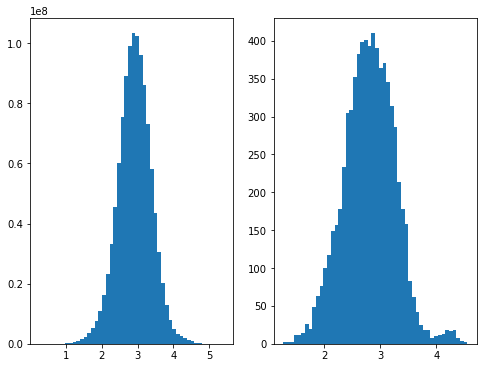

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(8, 6))

axs[0].hist(glob_dist[np.triu_indices(glob_dist.shape[0], k=1)], bins=50)
axs[1].hist(lib_dist[np.triu_indices(lib_dist.shape[0], k=1)], bins=50)
plt.show()

In [24]:
def hamming_dist(seq1, seq2):
    """compute hamming distance between 2 strings"""
    dist = 0
    if len(seq1) == len(seq2):
        for i, l in enumerate(seq1):
            if l != seq2[i]:
                dist += 1
        return(dist)
    else:
        print('HAMMING: sequences of different length')

def dist_mat(lib):
    """compute distance matrix given a function"""
    dim = len(lib)
    dmat = np.empty((dim, dim))
    for i in range(dim):
        for j in range(dim):
            dmat[i, j] = hamming_dist(lib[i], lib[j])
    return(dmat)

In [176]:
# edit distance-based analysis
medoid_library = peptides[kmed]
hdist = dist_mat(pagg_pepseqs)

IndexError: arrays used as indices must be of integer (or boolean) type

In [106]:
from scipy.cluster import hierarchy

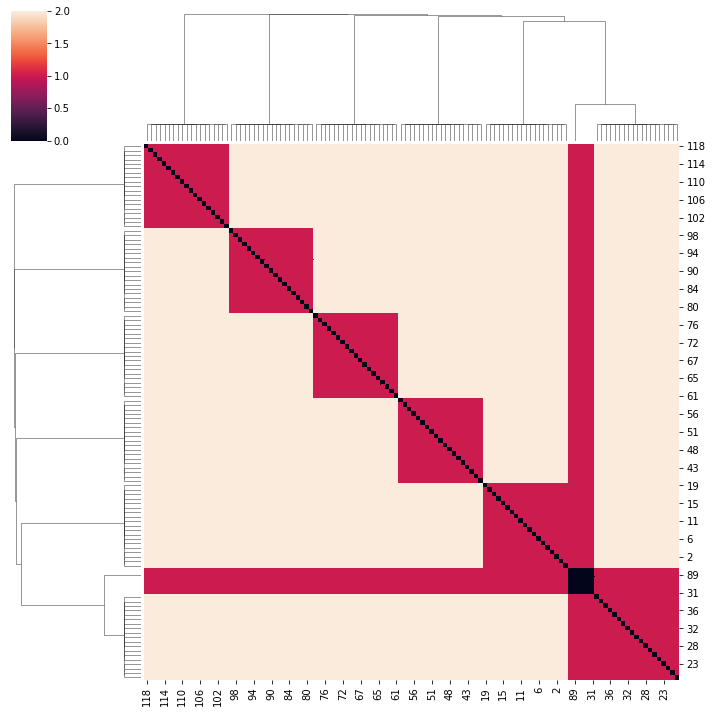

In [128]:
# define distance array as in linked answer
dist_array = ssd.squareform(hdist) 
# define linkage object
linkages = hierarchy.linkage(dist_array, method='ward')

sns.clustermap(hdist, row_linkage=linkages, col_linkage=linkages)

# SOM based library selection

In [14]:
from sklearn_som.som import SOM

In [15]:
pepti_som = SOM(m=10, n=10, dim=1900, random_state=88)
pepti_som.fit(data, epochs=5)

In [16]:
som_pred = pepti_som.predict(data)

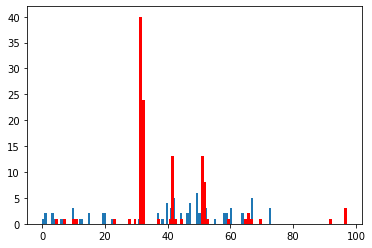

In [17]:
plt.hist(pepti_som.predict(orig_lib), bins=100)
plt.hist(pepti_som.predict(pagg_lib), color='r', bins=100)

plt.show()

In [18]:
neurons = pepti_som.cluster_centers_.reshape(100, 1900)

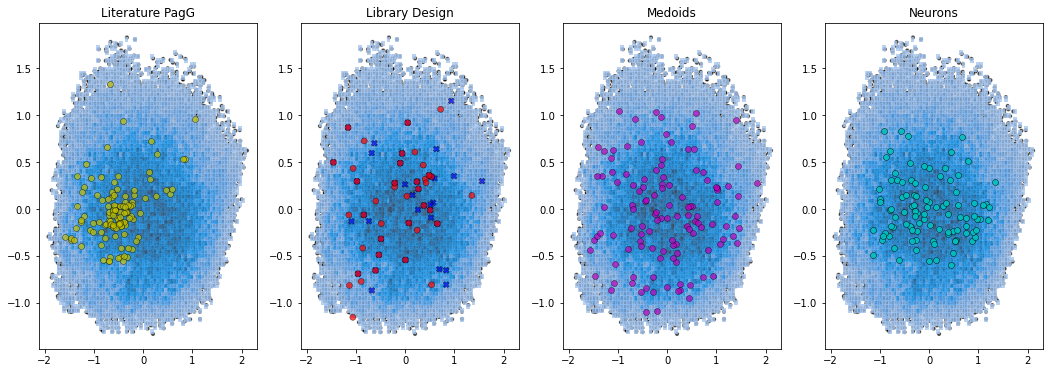

In [19]:
xx, yy = 0, 3

fig, axs = plt.subplots(1,4, figsize=(18,6))

for ax in axs:
    sns.scatterplot(x=X_transform[:, xx], y=X_transform[:, yy], alpha=0.7,color='k',size=0.1,legend=False, ax=ax)
                    #hue=kmed.labels_, palette='deep', legend=False)
    sns.histplot(x=X_transform[:, xx], y=X_transform[:, yy], bins=70, alpha=0.8, ax=ax)

sns.scatterplot(x=kmed.cluster_centers_[:, xx],
                y=kmed.cluster_centers_[:, yy],
                #hue=range(len(kmed.cluster_centers_)), palette='deep',
                color='m',
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[2])

sns.scatterplot(x=pca.transform(pagg_lib)[:, xx],
                y=pca.transform(pagg_lib)[:, yy],
                # hue=range(len(kmed.cluster_centers_)), palette='deep',
                color='y',
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[0])

sns.scatterplot(x=pca.transform(orig_lib)[:, xx],
                y=pca.transform(orig_lib)[:, yy],
                c=np.concatenate((['b' for i in range(40)],
                                  ['r' for i in range(40)])),
                palette='deep',
                style=np.concatenate(([3 for i in range(40)],
                                      [2 for i in range(40)])),
                edgecolor='k', legend=False,
                alpha=0.7, ax=axs[1])

sns.scatterplot(x=pca.transform(neurons)[:, xx], 
                y=pca.transform(neurons)[:, yy], 
                # hue=range(len(kmed.cluster_centers_)), palette='deep',
                color='c',
                edgecolor='k', legend=False,
                alpha=0.9, ax=axs[3])

axs[0].set_title('Literature PagG')
axs[1].set_title('Library Design')
axs[2].set_title('Medoids')
axs[3].set_title('Neurons')

plt.show()

In [20]:
from sklearn.neighbors import NearestNeighbors

In [21]:
neigh = NearestNeighbors(n_neighbors=1, radius=1, metric='euclidean')
neigh.fit(data)

NearestNeighbors(metric='euclidean', n_neighbors=1, radius=1)

In [30]:
som_lib = neigh.kneighbors(neurons[:], 5, return_distance=False)

In [23]:
peptides[som_lib].reshape(100)

array(['YKLS', 'TAFR', 'SKFA', 'SRQV', 'SRNE', 'NESR', 'DQSR', 'ESDR',
       'ETRE', 'EHTK', 'YRAN', 'AFEK', 'AETR', 'TEHA', 'SETH', 'HESN',
       'EHSK', 'ESQV', 'QENF', 'EKFQ', 'YQAD', 'VENW', 'TELN', 'TENA',
       'TEGN', 'KDTR', 'KDTR', 'KSEL', 'QFEK', 'QRNF', 'FQAD', 'VDKF',
       'ISER', 'TEGL', 'GDRS', 'GVKD', 'KANY', 'KQYV', 'KQFS', 'RNKA',
       'FRAN', 'VERF', 'IQRF', 'IGER', 'GEHF', 'GFRE', 'KQFV', 'KSYL',
       'RTFE', 'RESY', 'FVQR', 'VFRQ', 'VRQF', 'VRNW', 'DGFR', 'DQVW',
       'KHFA', 'RNIY', 'RQFW', 'RANW', 'WQRI', 'WVQK', 'VRNW', 'DWVK',
       'DYQA', 'DRNF', 'NFRD', 'HFRE', 'RKFC', 'RCFE', 'WRQD', 'WRAN',
       'AWEV', 'EYVS', 'DYCQ', 'DTRC', 'NTEC', 'HKCF', 'KCYQ', 'RHCK',
       'WQGD', 'CFER', 'CYAK', 'EYLC', 'EFCQ', 'EVCN', 'TECF', 'YCEI',
       'HCEI', 'HKCR', 'CDRF', 'CDRA', 'CNRI', 'CRIS', 'EVCH', 'TECF',
       'TCFE', 'ICNR', 'ICNR', 'VYGK'], dtype='<U4')

In [31]:
matches = set(orig_peptides).intersection(set(peptides[som_lib].flatten()))
print('No. of matches ='+str(len(matches)))
print(matches)

No. of matches =0
set()


In [25]:
len(set([str(i) for i in peptides[som_lib].reshape(100)]))

96